# ==============================================================
# Limpeza e Tratamento Avançado de Dados de Vendas
# Henry - Ciência de Dados
# ==============================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from sklearn.linear_model import LinearRegression

# Configurações globais de exibição
pd.set_option('display.float_format', lambda x: f'R$ {x:,.2f}')
sns.set_style("whitegrid")

In [2]:
# 1. Carregar CSV
# -------------------------------
df = pd.read_csv("Relatório gerencial.csv", encoding="utf-8", sep=",")

In [3]:
# -------------------------------
# 2. Padronizar colunas
# -------------------------------
df.columns = (
    df.columns.str.strip()
    .str.replace(" ", "_")
    .str.replace(".", "", regex=False)
    .str.replace("ç","c")
    .str.replace("ã","a")
    .str.replace("ó","o")
)
# Colunas esperadas: ['Codigo_da_Venda', 'Produto', 'Qtd', 'Data', 'Hora', 'Cliente', 'Vendedor', 'Forma_de_Pagamento', 'Valor_Unit', 'Subtotal']


In [4]:
# -------------------------------
# 3. Limpeza e conversão de dados
# -------------------------------
# Valores monetários
for col in ['Valor_Unit','Subtotal']:
    df[col] = df[col].astype(str).str.replace('R$', '', regex=False).str.replace(',', '.').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Quantidade
df['Qtd'] = pd.to_numeric(df['Qtd'], errors='coerce')

# Datas e horários
df['Data'] = pd.to_datetime(df['Data'], dayfirst=True, errors='coerce')
df['Hora'] = pd.to_datetime(df['Hora'], format='%H:%M', errors='coerce').dt.time
df['Data_Hora'] = pd.to_datetime(df['Data'].astype(str) + ' ' + df['Hora'].astype(str))

# Strings
df['Produto'] = df['Produto'].str.strip().str.title()
df['Forma_de_Pagamento'] = df['Forma_de_Pagamento'].str.strip().str.title()

# Remover duplicatas e nulos essenciais
df = df.drop_duplicates(subset=['Codigo_da_Venda'])
df = df.dropna(subset=['Produto', 'Qtd', 'Valor_Unit', 'Subtotal', 'Data'])

# Verificar subtotal
df['Subtotal_Verificado'] = df['Qtd'] * df['Valor_Unit']
df['Erro_Subtotal'] = (df['Subtotal_Verificado'] != df['Subtotal']).astype(int)
df['Diferenca_Subtotal'] = df['Subtotal_Verificado'] - df['Subtotal']


In [5]:
# -------------------------------
# 4. Criar colunas extras
# -------------------------------
df['Dia_da_Semana'] = df['Data'].dt.day_name()
df['Mes'] = df['Data'].dt.month
df['Ano'] = df['Data'].dt.year
df['Hora_do_Dia'] = pd.to_datetime(df['Hora'], format='%H:%M:%S', errors='coerce').dt.hour
df['Periodo_do_Dia'] = pd.cut(df['Hora_do_Dia'], bins=[0,12,18,24], labels=['Manha','Tarde','Noite'], right=False)
df['Ticket'] = df['Subtotal'] / df['Qtd']
df['Semana_do_Ano'] = df['Data_Hora'].dt.isocalendar().week
df['Trimestre'] = df['Data_Hora'].dt.quarter
df['Periodo_do_Mes'] = pd.cut(df['Data_Hora'].dt.day, bins=[0,10,20,31], labels=['Inicio','Meio','Fim'])

# Categorias de produto
df['Categoria'] = df['Produto'].str.extract(r'(Pijama|Fantasia|Vestido|Conjunto|Meia|Body)', expand=False)

# Clientes: novo ou recorrente
df['Tipo_Cliente'] = df.duplicated(subset=['Cliente'], keep=False).map({True: 'Recorrente', False: 'Novo'})

# Ticket médio e frequência por cliente
ticket_cliente = df.groupby('Cliente')['Subtotal'].mean().reset_index().rename(columns={'Subtotal':'Ticket_Cliente'})
freq_cliente = df.groupby('Cliente')['Codigo_da_Venda'].nunique().reset_index().rename(columns={'Codigo_da_Venda':'Freq_Cliente'})
df = df.merge(ticket_cliente, on='Cliente', how='left').merge(freq_cliente, on='Cliente', how='left')

# Formas de pagamento simplificadas
def padroniza_pagamento(x):
    x = str(x).lower()
    if 'dinheiro' in x: return 'Dinheiro'
    elif 'pix' in x: return 'Pix'
    elif 'cartão' in x: return 'Cartão'
    else: return x.title()
df['Forma_de_Pagamento_Simples'] = df['Forma_de_Pagamento'].apply(padroniza_pagamento)

# Ticket médio por forma
ticket_fp = df.groupby('Forma_de_Pagamento_Simples')['Subtotal'].mean().reset_index().rename(columns={'Subtotal':'Ticket_Medio_Forma'})
df = df.merge(ticket_fp, on='Forma_de_Pagamento_Simples', how='left')

# Feriados Brasil
anos = df['Ano'].unique()
br_holidays = holidays.Brazil(years=anos)
df['Feriado'] = df['Data_Hora'].dt.date.apply(lambda x: x in br_holidays)


In [6]:
# -------------------------------
# 5. Outliers
# -------------------------------
Q1 = df['Subtotal'].quantile(0.25)
Q3 = df['Subtotal'].quantile(0.75)
IQR = Q3 - Q1
df['Outlier'] = (df['Subtotal'] < Q1 - 1.5*IQR) | (df['Subtotal'] > Q3 + 1.5*IQR)
df['Outlier_Ticket'] = df['Subtotal'] > df['Subtotal'].quantile(0.95)


In [10]:
# -------------------------------
# 6. Métricas principais
# -------------------------------
total_vendas = df['Subtotal'].sum()
total_itens = df['Qtd'].sum()
ticket_medio_geral = df['Ticket'].mean()

# Top 10 produtos por faturamento
top_produtos = df.groupby('Produto')['Subtotal'].sum().sort_values(ascending=False).head(10)

# Pareto 80%
df_sorted = df.groupby('Produto')['Subtotal'].sum().sort_values(ascending=False).reset_index()
df_sorted['Acumulado'] = df_sorted['Subtotal'].cumsum()
df_sorted['Percentual'] = df_sorted['Acumulado'] / df_sorted['Subtotal'].sum()
pareto_80 = df_sorted[df_sorted['Percentual'] <= 0.8]

# Vendas por forma de pagamento
vendas_forma_total = df.groupby('Forma_de_Pagamento_Simples')['Subtotal'].sum()
total_geral_formas = vendas_forma_total.sum()
percent_fp = (vendas_forma_total / total_geral_formas * 100).reset_index().rename(columns={'Subtotal':'Percentual_Forma'})

# Ranking clientes por faturamento
ranking_cliente = df.groupby('Cliente')['Subtotal'].sum().sort_values(ascending=False).reset_index()
ranking_cliente['Ranking_Cliente'] = range(1,len(ranking_cliente)+1)

# Ticket médio por cliente já calculado
# Frequência já calculada



In [9]:
# -------------------------------
# 7. Segmentação RFM
# -------------------------------
data_ref = df['Data_Hora'].max()
rfm = df.groupby('Cliente').agg({
    'Data_Hora': lambda x: (data_ref - x.max()).days,  
    'Codigo_da_Venda': 'nunique',                       
    'Subtotal': 'sum'                                   
}).reset_index()
rfm.columns = ['Cliente','Recency','Frequency','Monetary']

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'].astype(str)+rfm['F_Score'].astype(str)+rfm['M_Score'].astype(str)

def classificar_cliente(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Clientes VIP'
    elif row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Clientes Fiéis'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'Clientes em Risco'
    elif row['Frequency'] == 1:
        return 'Clientes Novos'
    else:
        return 'Clientes Regulares'
rfm['Segmento'] = rfm.apply(classificar_cliente, axis=1)

In [ ]:

# 8. Faturamento por períodos
# -------------------------------
faturamento_diario = df.groupby('Data')['Subtotal'].sum().reset_index().rename(columns={'Subtotal':'Faturamento'})
faturamento_semanal = df.groupby('Semana_do_Ano')['Subtotal'].sum().reset_index().rename(columns={'Subtotal':'Faturamento'})
faturamento_mensal = df.groupby('Mes')['Subtotal'].sum().reset_index().rename(columns={'Subtotal':'Faturamento'})
faturamento_trimestral = df.groupby('Trimestre')['Subtotal'].sum().reset_index().rename(columns={'Subtotal':'Faturamento'})


[(datetime.date(2025, 1, 1), 'Confraternização Universal'), (datetime.date(2025, 4, 18), 'Sexta-feira Santa'), (datetime.date(2025, 4, 21), 'Tiradentes'), (datetime.date(2025, 5, 1), 'Dia do Trabalhador'), (datetime.date(2025, 9, 7), 'Independência do Brasil')]


In [ ]:
# 9. Previsão simples Linear (7 dias)
# -------------------------------
faturamento_diario['Dia_Num'] = np.arange(len(faturamento_diario))
X = faturamento_diario[['Dia_Num']]
y = faturamento_diario['Faturamento']
modelo = LinearRegression()
modelo.fit(X, y)
dias_futuros = pd.DataFrame({'Dia_Num': np.arange(len(faturamento_diario), len(faturamento_diario)+7)})
previsao = modelo.predict(dias_futuros)
previsao_df = pd.DataFrame({'Dia_Futuro': range(1,8), 'Faturamento_Previsto': previsao})


In [ ]:
# 10. Observações automáticas e alertas
# -------------------------------
observacoes = []

# Produtos com diferença no subtotal
produtos_errados = df[df['Erro_Subtotal']==1]['Produto'].unique()
if len(produtos_errados) > 0:
    observacoes.append(f"Produtos com diferença no subtotal: {produtos_errados}")

# Produtos de baixo volume mas alto ticket
low_volume_high_ticket = df[(df['Qtd'] < df['Qtd'].quantile(0.25)) & (df['Ticket'] > df['Ticket'].quantile(0.75))]
if not low_volume_high_ticket.empty:
    observacoes.append(f"Produtos de baixo volume e alto ticket: {low_volume_high_ticket['Produto'].unique()}")

# Dias com faturamento muito alto (2x média)
media_diaria = faturamento_diario['Faturamento'].mean()
outlier_dias = faturamento_diario[faturamento_diario['Faturamento'] > 2*media_diaria]
if not outlier_dias.empty:
    observacoes.append(f"Dias com faturamento muito alto: {list(outlier_dias['Data'])}")

# %% [markdown]
# ## ✅ Próximos passos:
# - Adicionar gráficos automáticos por seção: Produtos, Clientes, Temporalidade, Formas de pagamento
# - Gerar relatório PDF ou Excel com todas as métricas e insights
# - Destacar alertas e outliers visualmente
# - Interpretar cada gráfico com texto curto para o cliente

In [11]:

print("===== VISÃO EXECUTIVA =====")
print(f"Faturamento total: R$ {total_vendas:,.2f}")
print(f"Itens vendidos: {total_itens}")
print(f"Ticket médio geral: R$ {ticket_medio_geral:,.2f}")
print(f"Número de clientes: {df['Cliente'].nunique()}")
print(f"Clientes recorrentes: {len(df[df['Tipo_Cliente']=='Recorrente']['Cliente'].unique())}")
print(f"Clientes novos: {len(df[df['Tipo_Cliente']=='Novo']['Cliente'].unique())}")


===== VISÃO EXECUTIVA =====
Faturamento total: R$ 62,427.51
Itens vendidos: 1396
Ticket médio geral: R$ 48.04
Número de clientes: 2
Clientes recorrentes: 1
Clientes novos: 1


C:\Users\msn_j.000\AppData\Local\Temp\ipykernel_19932\2422089407.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(produtos_stats.index, rotation=45, ha='right')


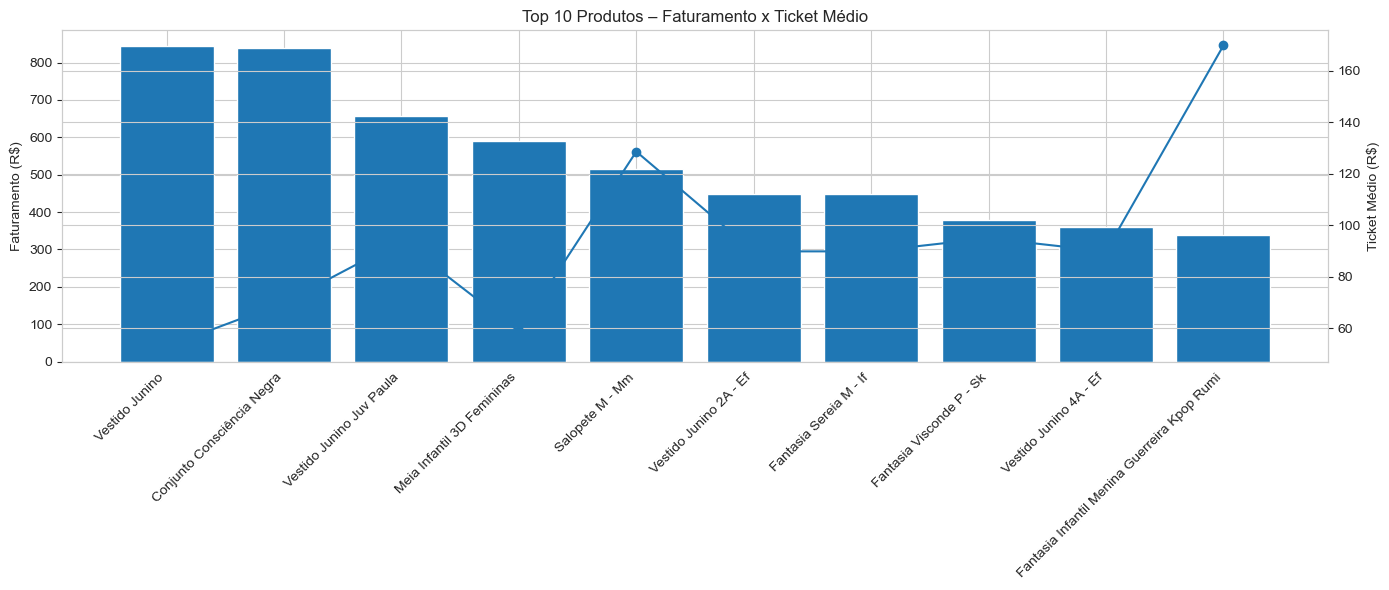

In [12]:
produtos_stats = df.groupby('Produto').agg(
    Faturamento=('Subtotal','sum'),
    Ticket_Medio=('Ticket','mean'),
    Quantidade=('Qtd','sum')
).sort_values('Faturamento', ascending=False).head(10)

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(produtos_stats.index, produtos_stats['Faturamento'])
ax1.set_ylabel("Faturamento (R$)")
ax1.set_xticklabels(produtos_stats.index, rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(produtos_stats.index, produtos_stats['Ticket_Medio'], marker='o')
ax2.set_ylabel("Ticket Médio (R$)")

plt.title("Top 10 Produtos – Faturamento x Ticket Médio")
plt.tight_layout()
plt.show()



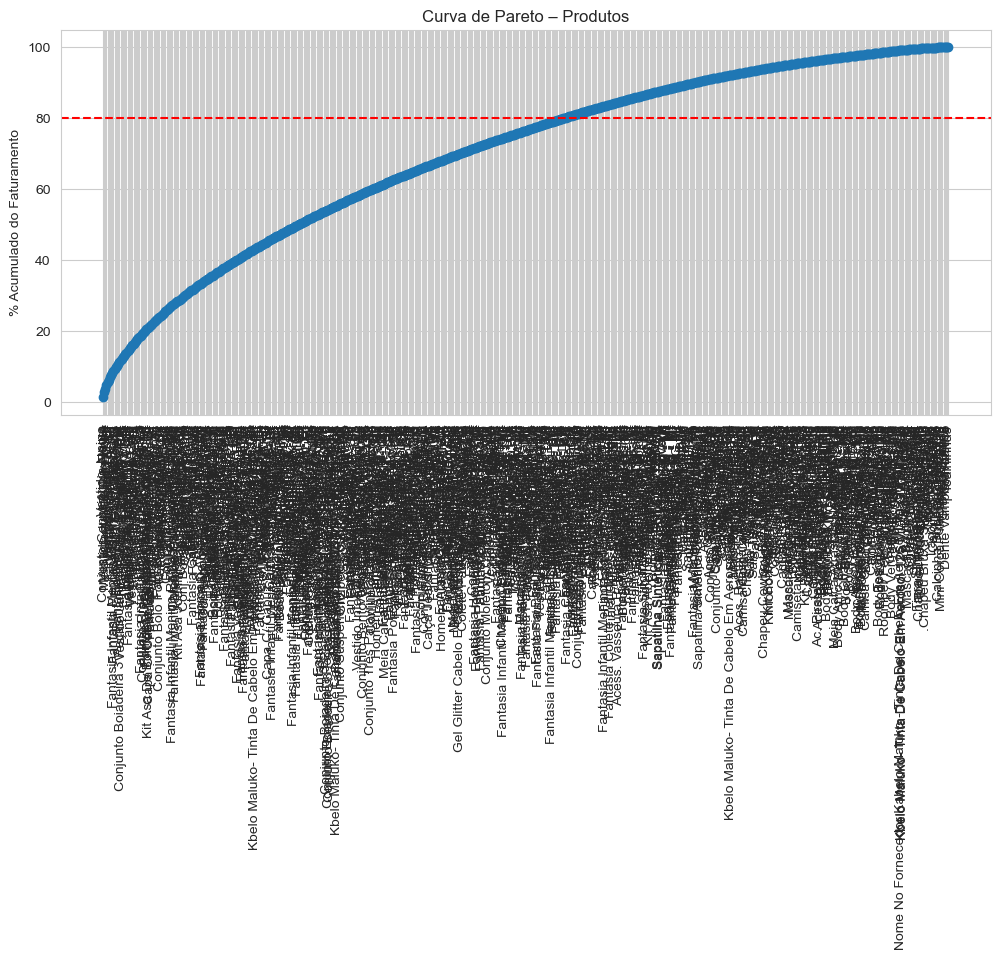

In [13]:
plt.figure(figsize=(12,5))
plt.plot(df_sorted['Produto'], df_sorted['Percentual']*100, marker='o')
plt.axhline(80, color='red', linestyle='--')
plt.xticks(rotation=90)
plt.ylabel('% Acumulado do Faturamento')
plt.title('Curva de Pareto – Produtos')
plt.show()


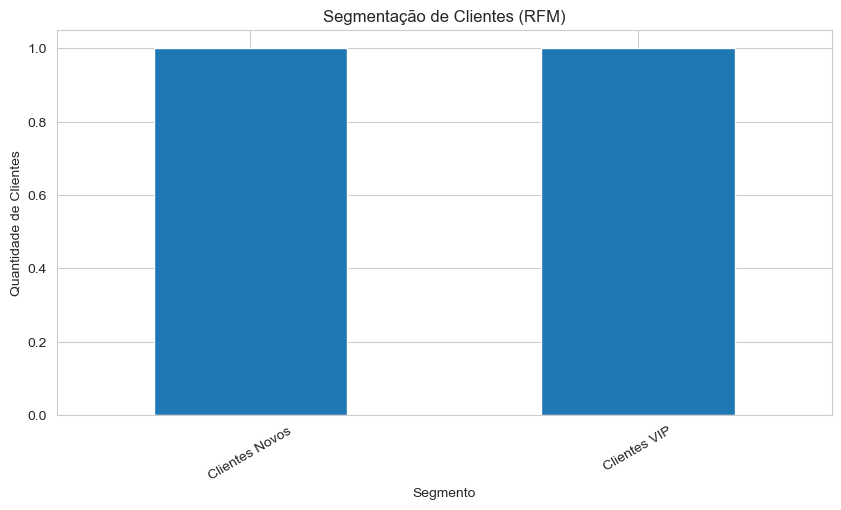

In [14]:
segmentos = rfm['Segmento'].value_counts()

plt.figure(figsize=(10,5))
segmentos.plot(kind='bar')
plt.title("Segmentação de Clientes (RFM)")
plt.ylabel("Quantidade de Clientes")
plt.xticks(rotation=30)
plt.show()



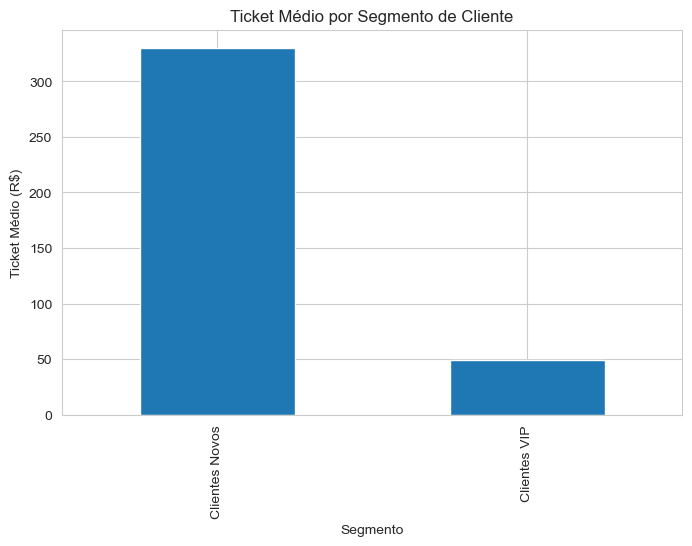

In [15]:
ticket_segmento = rfm.merge(
    df.groupby('Cliente')['Subtotal'].mean().reset_index(),
    on='Cliente'
).groupby('Segmento')['Subtotal'].mean()

ticket_segmento.plot(kind='bar', figsize=(8,5))
plt.title("Ticket Médio por Segmento de Cliente")
plt.ylabel("Ticket Médio (R$)")
plt.show()


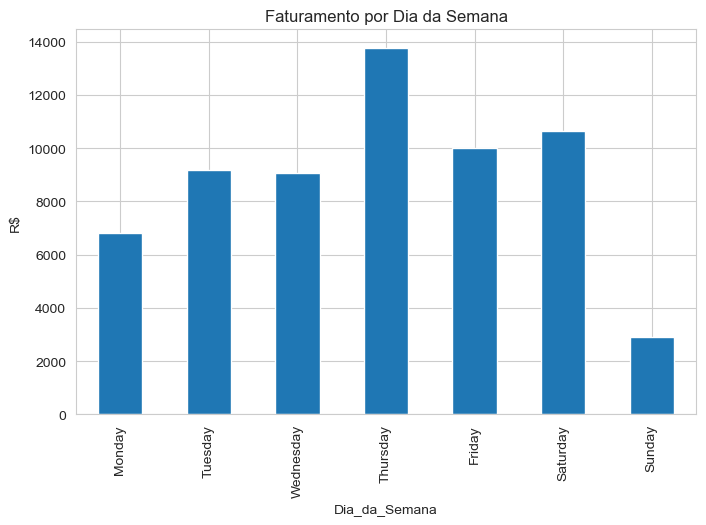

In [16]:
vendas_dia = df.groupby('Dia_da_Semana')['Subtotal'].sum()
vendas_dia = vendas_dia.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

vendas_dia.plot(kind='bar', figsize=(8,5))
plt.title("Faturamento por Dia da Semana")
plt.ylabel("R$")
plt.show()


In [17]:
plt.figure(figsize=(14,5))
plt.plot(faturamento_diario['Data'], faturamento_diario['Faturamento'], label='Faturamento')
plt.scatter(
    df[df['Feriado']]['Data'],
    df[df['Feriado']]['Subtotal'],
    color='red',
    label='Feriados',
    alpha=0.6
)
plt.legend()
plt.title("Impacto de Feriados no Faturamento")
plt.show()


NameError: name 'faturamento_diario' is not defined

<Figure size 1400x500 with 0 Axes>

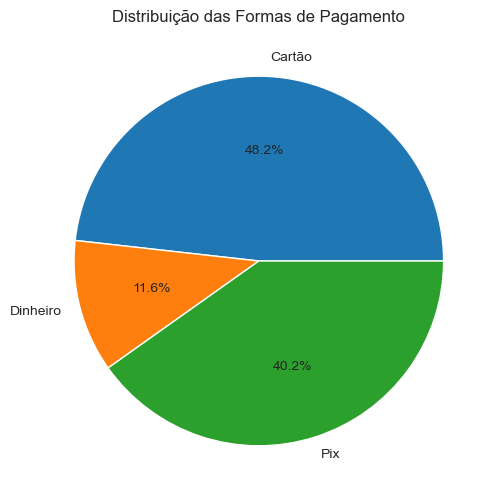

In [18]:
vendas_forma_total.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Distribuição das Formas de Pagamento")
plt.ylabel("")
plt.show()


In [19]:
print("===== ALERTAS IMPORTANTES =====")

print(f"Vendas com erro de subtotal: {df['Erro_Subtotal'].sum()}")
print(f"Outliers de venda: {df['Outlier'].sum()}")
print(f"Outliers de ticket: {df['Outlier_Ticket'].sum()}")


===== ALERTAS IMPORTANTES =====
Vendas com erro de subtotal: 1
Outliers de venda: 15
Outliers de ticket: 57


In [20]:
plt.figure(figsize=(12,5))
plt.plot(faturamento_diario['Data'], faturamento_diario['Faturamento'], label='Histórico')
plt.plot(
    pd.date_range(faturamento_diario['Data'].max(), periods=8, freq='D')[1:],
    previsao,
    linestyle='--',
    label='Previsão'
)
plt.legend()
plt.title("Previsão de Faturamento (Curto Prazo)")
plt.show()


NameError: name 'faturamento_diario' is not defined

<Figure size 1200x500 with 0 Axes>

In [21]:
# -------------------------------
# 8. Detecção de outliers
# -------------------------------
Q1 = df['Subtotal'].quantile(0.25)
Q3 = df['Subtotal'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Subtotal'] < Q1 - 1.5*IQR) | (df['Subtotal'] > Q3 + 1.5*IQR)]


In [22]:
# -------------------------------
# 9. Observações automáticas
# -------------------------------
observacoes = []

# Produtos com diferença no subtotal
produtos_errados = df[df['Diferenca_Subtotal'] != 0]['Produto'].unique()
if len(produtos_errados) > 0:
    observacoes.append(f"Produtos com diferença no subtotal: {produtos_errados}")

# Produtos de baixo volume mas alto ticket
low_volume_high_ticket = df[df['Qtd'] < df['Qtd'].quantile(0.25)]
observacoes.append(f"Produtos de baixo volume e alto ticket: {low_volume_high_ticket['Produto'].unique()}")

In [23]:
# -------------------------------
# 11. Exibir métricas principais
# -------------------------------

# Métricas Gerais
print("=== MÉTRICAS GERAIS ===")
print(f"Total de vendas: R$ {total_vendas:.2f}")
print(f"Total de itens vendidos: {total_itens}")
print(f"Ticket médio geral: R$ {ticket_medio_geral:.2f}\n")

# Top 10 Produtos por Faturamento
print("=== TOP 10 PRODUTOS POR FATURAMENTO ===")
print(top_produtos.to_string())
print()


# Vendas por forma de pagamento (incluindo Dinheiro e PIX)
print("=== VENDAS POR FORMA DE PAGAMENTO ===")
vendas_forma_total = df.groupby('Forma_de_Pagamento_Simples')['Subtotal'].sum()  # soma por forma simples
total_geral_formas = vendas_forma_total.sum()
print(vendas_forma_total.to_string())
print(f"TOTAL GERAL: R$ {total_geral_formas:.2f}\n")

# Outliers detectados
print("=== OUTLIERS DETECTADOS ===")
if not outliers.empty:
    print(outliers[['Codigo_da_Venda', 'Produto', 'Qtd', 'Subtotal']].to_string(index=False))
else:
    print("Nenhum outlier detectado.\n")

# Observações automáticas
print("=== OBSERVAÇÕES AUTOMÁTICAS ===")
if observacoes:
    for obs in observacoes:
        print("-", obs)
else:
    print("Nenhuma observação automática gerada.")


=== MÉTRICAS GERAIS ===
Total de vendas: R$ 62427.51
Total de itens vendidos: 1396
Ticket médio geral: R$ 48.04

=== TOP 10 PRODUTOS POR FATURAMENTO ===
Produto
Vestido Junino                                 R$ 844.00
Conjunto Consciência Negra                     R$ 840.00
Vestido Junino Juv Paula                       R$ 658.00
Meia Infantil 3D Femininas                     R$ 589.00
Salopete M - Mm                                R$ 514.70
Vestido Junino 2A - Ef                         R$ 449.50
Fantasia Sereia M - If                         R$ 449.50
Fantasia Visconde P - Sk                       R$ 380.00
Vestido Junino 4A - Ef                         R$ 359.60
Fantasia Infantil Menina Guerreira Kpop Rumi   R$ 339.80

=== VENDAS POR FORMA DE PAGAMENTO ===
Forma_de_Pagamento_Simples
Cartão     R$ 30,105.51
Dinheiro    R$ 7,242.00
Pix        R$ 25,080.00
TOTAL GERAL: R$ 62427.51

=== OUTLIERS DETECTADOS ===
 Codigo_da_Venda                                                  Produto  Qt

In [24]:
# 1. Checar valores nulos
print(df.isna().sum())

# 2. Checar duplicatas (além de Codigo_da_Venda)
print(df.duplicated().sum())

# 3. Checar se o Subtotal bate com Qtd * Valor_Unit
df_erro_subtotal = df[df['Subtotal_Verificado'] != df['Subtotal']]
print(df_erro_subtotal[['Produto','Qtd','Valor_Unit','Subtotal','Subtotal_Verificado']])

# 4. Checar valores negativos
print(df[(df['Qtd']<0) | (df['Valor_Unit']<0) | (df['Subtotal']<0)])

# 5. Checar tipos de dados
print(df.dtypes)


Codigo_da_Venda                 0
Produto                         0
Qtd                             0
Data                            0
Hora                            0
Cliente                         0
Vendedor                        0
Forma_de_Pagamento              0
Valor_Unit                      0
Subtotal                        0
Data_Hora                       0
Subtotal_Verificado             0
Erro_Subtotal                   0
Diferenca_Subtotal              0
Dia_da_Semana                   0
Mes                             0
Ano                             0
Hora_do_Dia                     0
Periodo_do_Dia                  0
Ticket                          0
Semana_do_Ano                   0
Trimestre                       0
Periodo_do_Mes                  0
Categoria                     606
Tipo_Cliente                    0
Ticket_Cliente                  0
Freq_Cliente                    0
Forma_de_Pagamento_Simples      0
Ticket_Medio_Forma              0
Feriado       

In [25]:
# -------------------------------
# 11. Exibir métricas principais
# -------------------------------

# Métricas Gerais
print("=== MÉTRICAS GERAIS ===")
print(f"Total de vendas: R$ {total_vendas:.2f}")
print(f"Total de itens vendidos: {total_itens}")
print(f"Ticket médio geral: R$ {ticket_medio_geral:.2f}\n")

# Top 10 Produtos por Faturamento
print("=== TOP 10 PRODUTOS POR FATURAMENTO ===")
print(top_produtos.to_string())
print()


# Vendas por forma de pagamento (incluindo Dinheiro e PIX)
print("=== VENDAS POR FORMA DE PAGAMENTO ===")
vendas_forma_total = df.groupby('Forma_de_Pagamento_Simples')['Subtotal'].sum()  # soma por forma simples
total_geral_formas = vendas_forma_total.sum()
print(vendas_forma_total.to_string())
print(f"TOTAL GERAL: R$ {total_geral_formas:.2f}\n")

# Outliers detectados
print("=== OUTLIERS DETECTADOS ===")
if not outliers.empty:
    print(outliers[['Codigo_da_Venda', 'Produto', 'Qtd', 'Subtotal']].to_string(index=False))
else:
    print("Nenhum outlier detectado.\n")

# Observações automáticas
print("=== OBSERVAÇÕES AUTOMÁTICAS ===")
if observacoes:
    for obs in observacoes:
        print("-", obs)
else:
    print("Nenhuma observação automática gerada.")


=== MÉTRICAS GERAIS ===
Total de vendas: R$ 62427.51
Total de itens vendidos: 1396
Ticket médio geral: R$ 48.04

=== TOP 10 PRODUTOS POR FATURAMENTO ===
Produto
Vestido Junino                                 R$ 844.00
Conjunto Consciência Negra                     R$ 840.00
Vestido Junino Juv Paula                       R$ 658.00
Meia Infantil 3D Femininas                     R$ 589.00
Salopete M - Mm                                R$ 514.70
Vestido Junino 2A - Ef                         R$ 449.50
Fantasia Sereia M - If                         R$ 449.50
Fantasia Visconde P - Sk                       R$ 380.00
Vestido Junino 4A - Ef                         R$ 359.60
Fantasia Infantil Menina Guerreira Kpop Rumi   R$ 339.80

=== VENDAS POR FORMA DE PAGAMENTO ===
Forma_de_Pagamento_Simples
Cartão     R$ 30,105.51
Dinheiro    R$ 7,242.00
Pix        R$ 25,080.00
TOTAL GERAL: R$ 62427.51

=== OUTLIERS DETECTADOS ===
 Codigo_da_Venda                                                  Produto  Qt

graficos


In [283]:
# Estatísticas gerais numéricas
print(df.describe())

# Contagem de valores únicos por coluna
print(df.nunique())

# Olhando os primeiros registros
print(df.head())


       Codigo_da_Venda          Qtd                           Data  \
count      1259.000000  1259.000000                           1259   
mean        686.598888     1.108817  2025-09-10 13:20:38.125496320   
min          48.000000     1.000000            2025-06-02 00:00:00   
25%         373.500000     1.000000            2025-08-03 00:00:00   
50%         689.000000     1.000000            2025-09-28 00:00:00   
75%        1003.500000     1.000000            2025-10-25 00:00:00   
max        1319.000000    10.000000            2025-11-29 00:00:00   
std         366.863768     0.527534                            NaN   

        Valor_Unit     Subtotal  Subtotal_Verificado  Diferenca_Subtotal  \
count  1259.000000  1259.000000          1259.000000        1.259000e+03   
mean     48.036545    49.584996            49.584996       -1.128741e-17   
min       2.500000     2.500000             2.500000       -1.421085e-14   
25%      25.000000    25.000000            25.000000        0.000

Faturamento Total e Ticket Médi

C:\Users\msn_j.000\AppData\Local\Temp\ipykernel_19932\619172781.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


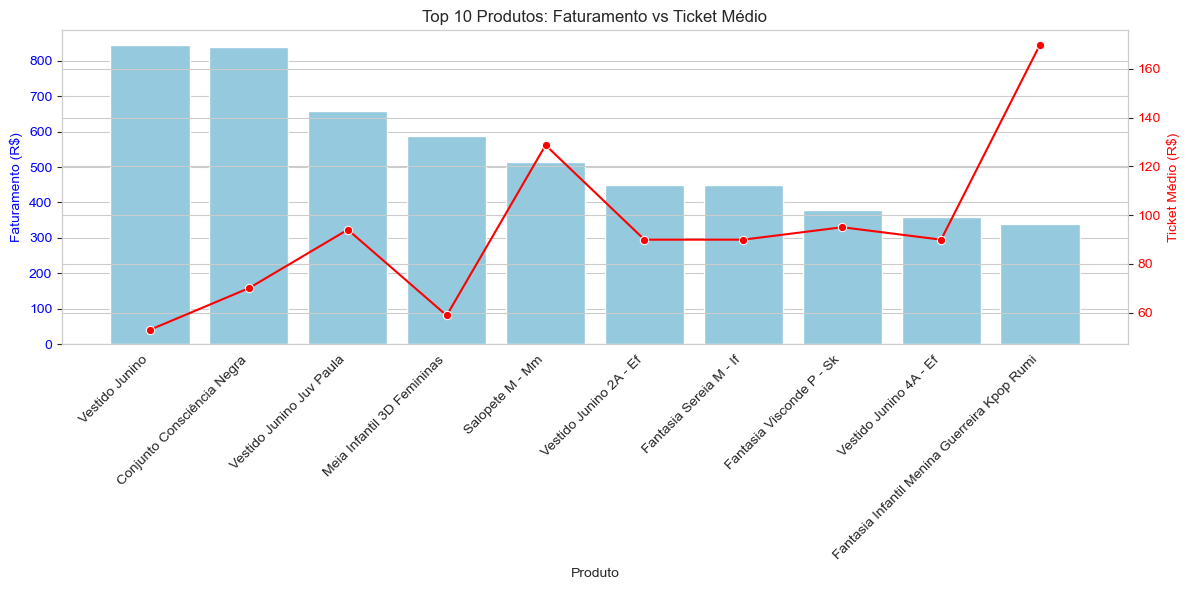

Faturamento total: R$ 62427.51
Ticket médio geral: R$ 48.04


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por produto: faturamento total e ticket médio
produtos_stats = df.groupby('Produto').agg({
    'Subtotal': 'sum',
    'Ticket': 'mean',
    'Qtd': 'sum'
}).reset_index().rename(columns={'Subtotal':'Faturamento', 'Ticket':'Ticket_Medio', 'Qtd':'Quantidade'})

# Ordenar pelo faturamento
produtos_stats = produtos_stats.sort_values('Faturamento', ascending=False).head(10)  # Top 10 produtos

# Criar figura
fig, ax1 = plt.subplots(figsize=(12,6))

# Barras: Faturamento
sns.barplot(
    x='Produto', 
    y='Faturamento', 
    data=produtos_stats, 
    ax=ax1, 
    color='skyblue'
)
ax1.set_ylabel('Faturamento (R$)', color='blue')
ax1.set_xlabel('Produto')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Linha: Ticket médio
ax2 = ax1.twinx()
sns.lineplot(
    x='Produto', 
    y='Ticket_Medio', 
    data=produtos_stats, 
    ax=ax2, 
    color='red', 
    marker='o'
)
ax2.set_ylabel('Ticket Médio (R$)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Top 10 Produtos: Faturamento vs Ticket Médio')
plt.tight_layout()
plt.show()

# Faturamento total
faturamento_total = df['Subtotal'].sum()
print(f"Faturamento total: R$ {faturamento_total:.2f}")

# Ticket médio geral
ticket_medio = df['Ticket'].mean()
print(f"Ticket médio geral: R$ {ticket_medio:.2f}")


# Como interpretar juntos:

# Produtos com barra alta + ponto vermelho alto → vendem bem e têm ticket alto → produtos muito estratégicos.

# Produtos com barra alta + ponto vermelho baixo → vendem muito, mas com ticket menor → volume de vendas compensa preço baixo.

# Produtos com barra baixa + ponto vermelho alto → vendem pouco, mas cada venda é cara → nicho ou produto premium.

# Produtos com barra baixa + ponto vermelho baixo → vendas baixas e ticket baixo → menos relevantes para o faturamento.

Vendas por Período 
Por dia da semana:

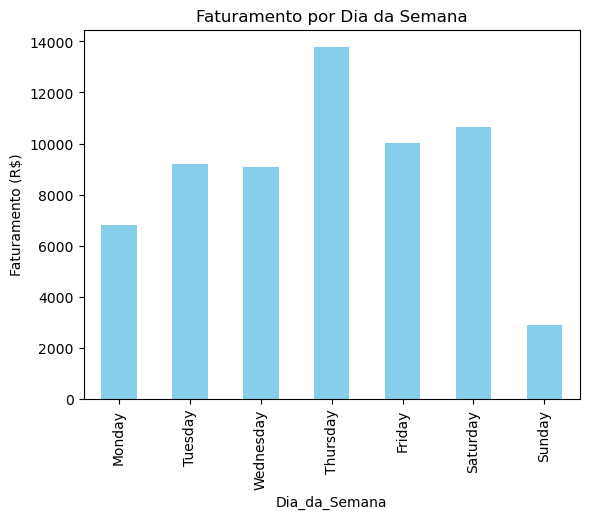

In [285]:
import matplotlib.pyplot as plt

vendas_dia = df.groupby('Dia_da_Semana')['Subtotal'].sum()
vendas_dia = vendas_dia.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

vendas_dia.plot(kind='bar', color='skyblue')
plt.title("Faturamento por Dia da Semana")
plt.ylabel("Faturamento (R$)")
plt.show()


Por mês 


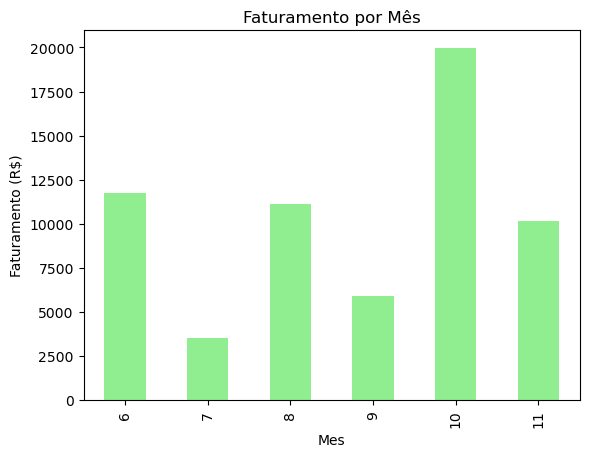

In [286]:
vendas_mes = df.groupby('Mes')['Subtotal'].sum()
vendas_mes.plot(kind='bar', color='lightgreen')
plt.title("Faturamento por Mês")
plt.ylabel("Faturamento (R$)")
plt.show()

trimestre

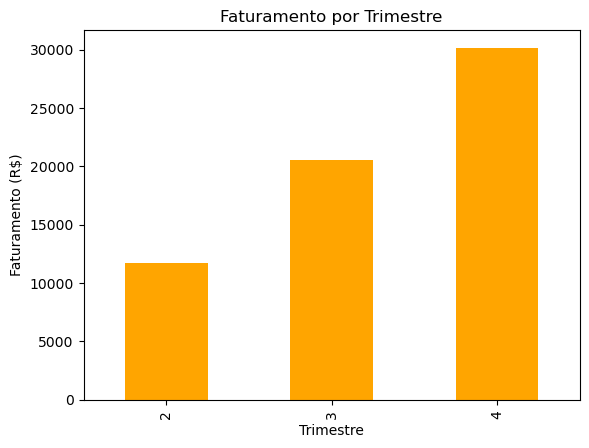

In [287]:
vendas_trimestre = df.groupby('Trimestre')['Subtotal'].sum()
vendas_trimestre.plot(kind='bar', color='orange')
plt.title("Faturamento por Trimestre")
plt.ylabel("Faturamento (R$)")
plt.show()

Produtos Mais Vendidos

                                              Faturamento  Quantidade
Produto                                                              
Vestido Junino                                      844.0          16
Conjunto Consciência Negra                          840.0          12
Vestido Junino Juv Paula                            658.0           7
Meia Infantil 3D Femininas                          589.0          10
Salopete M - Mm                                     514.7           4
Vestido Junino 2A - Ef                              449.5           5
Fantasia Sereia M - If                              449.5           5
Fantasia Visconde P - Sk                            380.0           4
Vestido Junino 4A - Ef                              359.6           4
Fantasia Infantil Menina Guerreira Kpop Rumi        339.8           2


C:\Users\msn_j.000\AppData\Local\Temp\ipykernel_19984\160421320.py:17: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



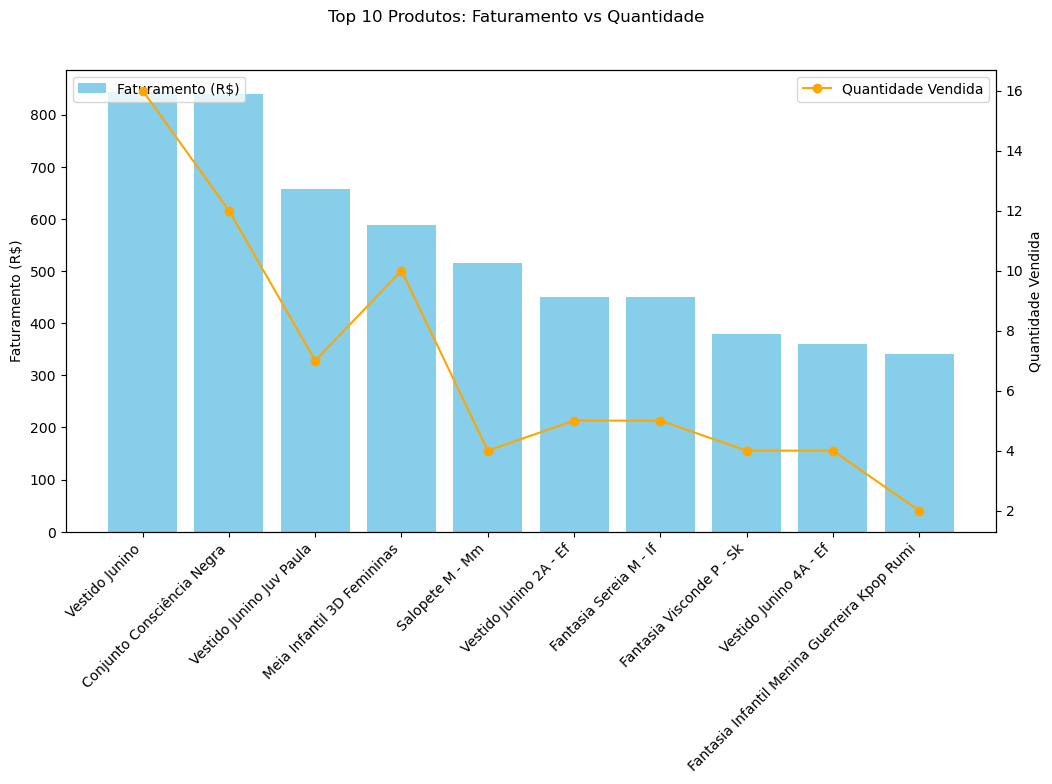

In [288]:
# Agrupar por produto: faturamento total e quantidade total vendida
produtos_stats = df.groupby('Produto').agg(
    Faturamento=('Subtotal', 'sum'),
    Quantidade=('Qtd', 'sum')
).sort_values(by='Faturamento', ascending=False).head(10)

print(produtos_stats)

# Visualização: faturamento vs quantidade
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

# Faturamento
ax1.bar(produtos_stats.index, produtos_stats['Faturamento'], color='skyblue', label='Faturamento (R$)')
ax1.set_ylabel('Faturamento (R$)')
ax1.set_xticklabels(produtos_stats.index, rotation=45, ha='right')

# Quantidade (linha sobreposta)
ax2 = ax1.twinx()
ax2.plot(produtos_stats.index, produtos_stats['Quantidade'], color='orange', marker='o', label='Quantidade Vendida')
ax2.set_ylabel('Quantidade Vendida')

# Título e legenda
fig.suptitle('Top 10 Produtos: Faturamento vs Quantidade')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()


Formas de Pagamento

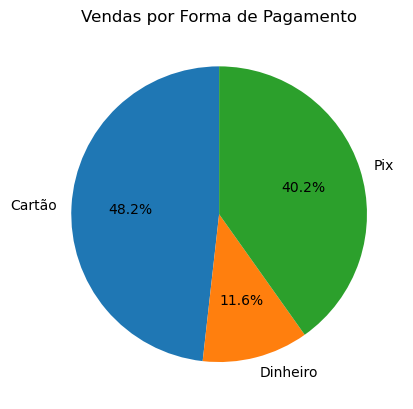

In [289]:
vendas_forma = df.groupby('Forma_de_Pagamento_Simples')['Subtotal'].sum()
vendas_forma.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Vendas por Forma de Pagamento")
plt.ylabel("")
plt.show()


In [290]:
# -------------------------------
# 1. Agrupar faturamento por dia e garantir tipo numérico
# -------------------------------
faturamento_diario = df.groupby('Data')['Subtotal'].sum().astype(float)

# Mostrar os faturamentos diários
print("=== Faturamento Diário ===")
print(faturamento_diario)

# -------------------------------
# 2. Calcular média diária
# -------------------------------
media_diaria = faturamento_diario.mean()
print(f"\nMédia diária: R${media_diaria:.2f}")

# -------------------------------
# 3. Identificar outliers (dias com faturamento > 2x média diária)
# -------------------------------
limite = 2 * media_diaria
outliers = faturamento_diario[faturamento_diario > limite]

print("\nDias com faturamento muito alto (possíveis outliers):")
if not outliers.empty:
    print(outliers)
else:
    print("Nenhum dia com faturamento muito alto detectado.")

=== Faturamento Diário ===
Data
2025-06-02    155.0
2025-06-03    639.7
2025-06-04    156.9
2025-06-05    606.6
2025-06-06    866.6
              ...  
2025-11-25    235.9
2025-11-26    468.4
2025-11-27    624.1
2025-11-28    543.0
2025-11-29    755.0
Name: Subtotal, Length: 155, dtype: float64

Média diária: R$402.76

Dias com faturamento muito alto (possíveis outliers):
Data
2025-06-06     866.60
2025-06-17    1194.20
2025-06-20     884.01
2025-06-21     975.40
2025-06-23    1097.40
2025-08-19    1239.10
2025-08-20    1395.90
2025-08-21    1683.90
2025-08-22     823.50
2025-10-03     892.50
2025-10-04    1124.30
2025-10-06     937.10
2025-10-07    1333.80
2025-10-08    2353.20
2025-10-09    2920.90
2025-10-30    1596.50
2025-11-01     941.70
Name: Subtotal, dtype: float64


In [291]:
# Média diária
media_diaria = faturamento_diario.mean()
print(f"Média diária calculada: R${media_diaria:.2f}")

# Soma total e número de dias, só pra conferir passo a passo
soma_total = faturamento_diario.sum()
num_dias = len(faturamento_diario)
media_manual = soma_total / num_dias
print(f"Soma total: R${soma_total:.2f}")
print(f"Número de dias: {num_dias}")
print(f"Média diária calculada manualmente: R${media_manual:.2f}")


Média diária calculada: R$402.76
Soma total: R$62427.51
Número de dias: 155
Média diária calculada manualmente: R$402.76


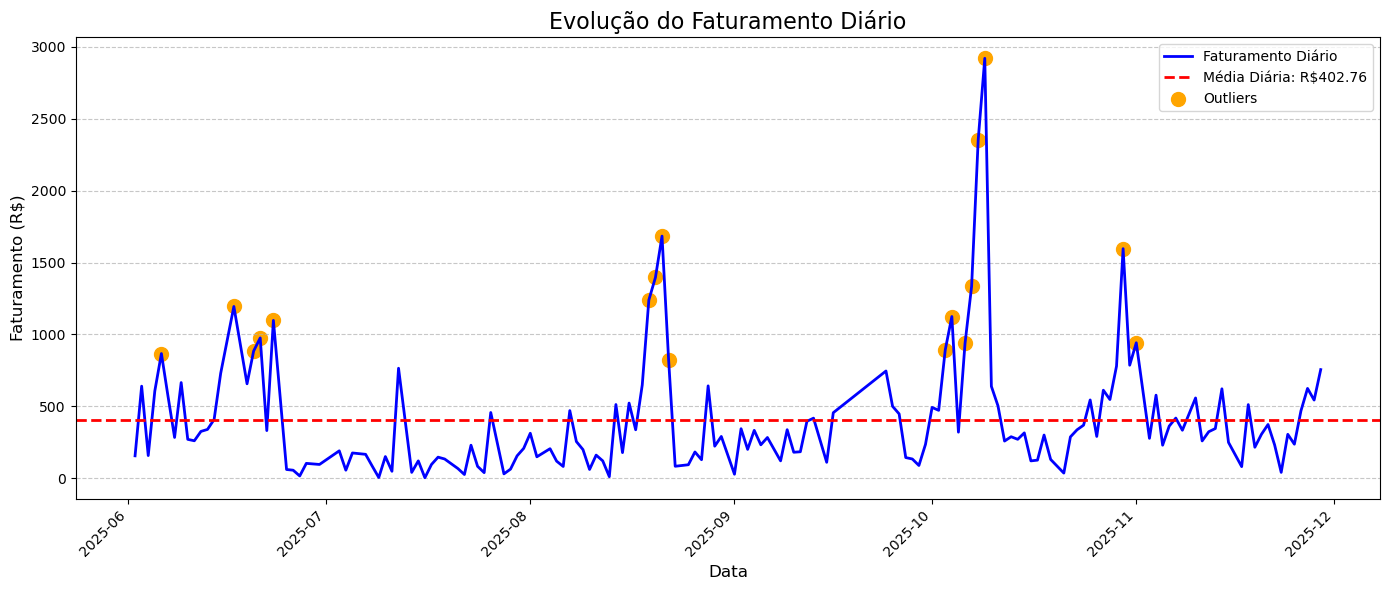

In [292]:
import matplotlib.pyplot as plt

# Faturamento diário
plt.figure(figsize=(14,6))
faturamento_diario.plot(color='blue', linewidth=2, label='Faturamento Diário')

# Média diária
media_diaria = faturamento_diario.mean()
plt.axhline(media_diaria, color='red', linestyle='--', linewidth=2, label=f'Média Diária: R${media_diaria:.2f}')

# Destacar outliers
limite = 2 * media_diaria
outliers = faturamento_diario[faturamento_diario > limite]
plt.scatter(outliers.index, outliers.values, color='orange', s=100, label='Outliers')

# Personalização
plt.title('Evolução do Faturamento Diário', fontsize=16)
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


Ticket Médio por Produto x Categoria

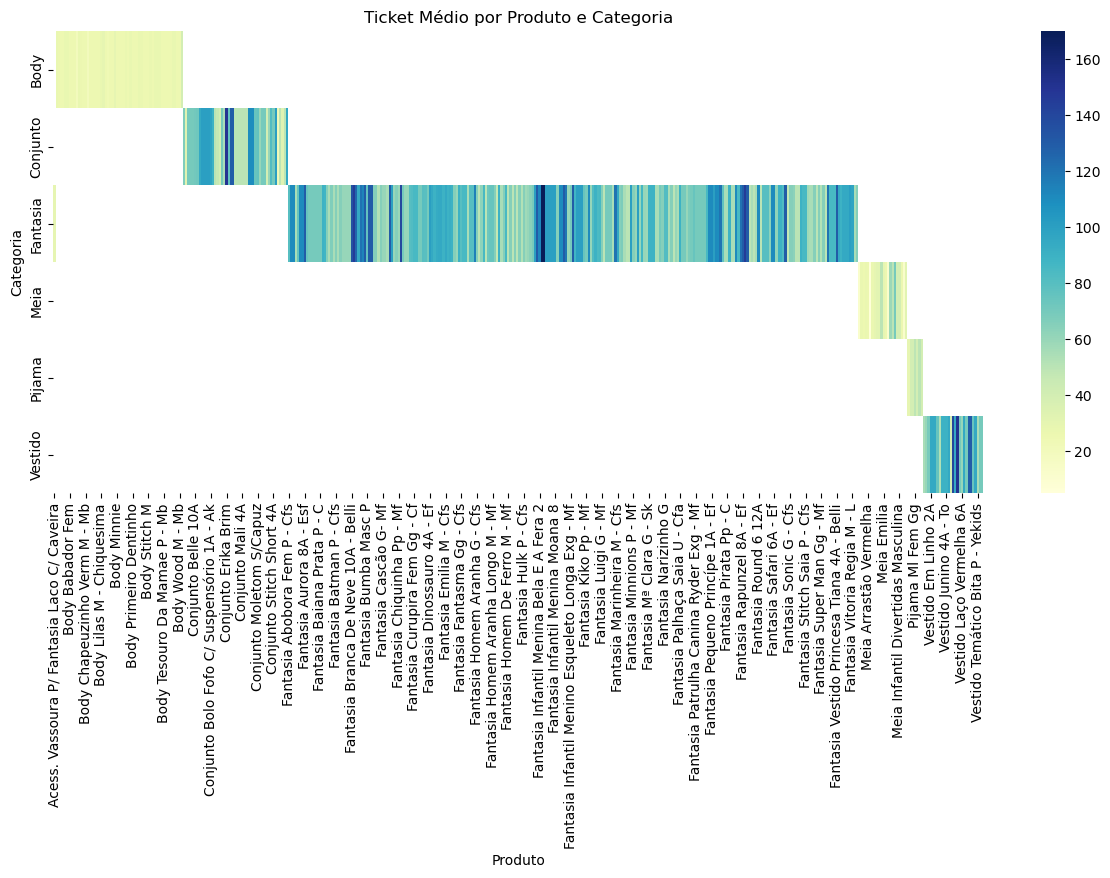

In [293]:
ticket_matrix = df.pivot_table(
    index='Categoria', 
    columns='Produto', 
    values='Ticket', 
    aggfunc='mean'
)

plt.figure(figsize=(15,6))
sns.heatmap(ticket_matrix, cmap='YlGnBu')
plt.title('Ticket Médio por Produto e Categoria')
plt.show()


In [294]:
import pandas as pd

# -------------------------------
# Métricas Gerais
# -------------------------------
metricas_gerais = {
    'Faturamento Total (R$)': total_vendas,
    'Total de Itens Vendidos': total_itens,
    'Ticket Médio Geral (R$)': ticket_medio_geral,
    'Clientes Recorrentes': len(df[df['Tipo_Cliente']=='Recorrente']['Cliente'].unique()),
    'Clientes Novos': len(df[df['Tipo_Cliente']=='Novo']['Cliente'].unique()),
    'Top Produto (Faturamento)': top_produtos.index[0],
    'Forma de Pagamento Mais Usada': vendas_forma_total.idxmax()
}

# -------------------------------
# Faturamento por Período
# -------------------------------
faturamento_diario = df.groupby('Data')['Subtotal'].sum().reset_index().rename(columns={'Subtotal':'Faturamento'})
faturamento_semanal = df.groupby('Semana_do_Ano')['Subtotal'].sum().reset_index().rename(columns={'Subtotal':'Faturamento'})
faturamento_mensal = df.groupby('Mes')['Subtotal'].sum().reset_index().rename(columns={'Subtotal':'Faturamento'})
faturamento_trimestral = df.groupby('Trimestre')['Subtotal'].sum().reset_index().rename(columns={'Subtotal':'Faturamento'})

# -------------------------------
# Top Produtos
# -------------------------------
top_10_produtos = top_produtos.reset_index().rename(columns={'Subtotal':'Faturamento'})

# Pareto 80%
pareto_80_produtos = pareto_80[['Produto','Subtotal','Percentual']]

# -------------------------------
# Ranking e Ticket de Clientes
# -------------------------------
ranking_clientes = ranking_cliente[['Cliente','Subtotal','Ranking_Cliente']]

ticket_clientes = ticket_cliente[['Cliente','Ticket_Cliente']]

# Frequência de compra
frequencia_clientes = freq_cliente[['Cliente','Freq_Cliente']]

# -------------------------------
# Formas de Pagamento
# -------------------------------
formas_pagamento = vendas_forma_total.reset_index().rename(columns={'Subtotal':'Faturamento'})
formas_pagamento_percentual = percent_fp[['Forma_de_Pagamento_Simples','Percentual_Forma']]

# Ticket médio por forma
ticket_por_forma = ticket_fp[['Forma_de_Pagamento_Simples','Ticket_Medio_Forma']]

# -------------------------------
# Outliers e alertas
# -------------------------------
outliers_vendas = df[df['Outlier']][['Codigo_da_Venda','Produto','Qtd','Subtotal']]
outliers_ticket = df[df['Outlier_Ticket']][['Codigo_da_Venda','Produto','Qtd','Subtotal']]
erros_subtotal = df[df['Erro_Subtotal']==1][['Codigo_da_Venda','Produto','Qtd','Valor_Unit','Subtotal','Subtotal_Verificado']]

# -------------------------------
# Consolidar métricas em dicionário
# -------------------------------
metricas_chave = {
    'Metricas Gerais': metricas_gerais,
    'Faturamento Diario': faturamento_diario,
    'Faturamento Semanal': faturamento_semanal,
    'Faturamento Mensal': faturamento_mensal,
    'Faturamento Trimestral': faturamento_trimestral,
    'Top 10 Produtos': top_10_produtos,
    'Pareto 80% Produtos': pareto_80_produtos,
    'Ranking Clientes': ranking_clientes,
    'Ticket por Cliente': ticket_clientes,
    'Frequencia Clientes': frequencia_clientes,
    'Formas de Pagamento': formas_pagamento,
    'Percentual por Forma': formas_pagamento_percentual,
    'Ticket Medio por Forma': ticket_por_forma,
    'Outliers Vendas': outliers_vendas,
    'Outliers Ticket': outliers_ticket,
    'Erros Subtotal': erros_subtotal
}

# -------------------------------
# Exemplo: acessar as métricas
# -------------------------------
print("=== Métricas Gerais ===")
for k,v in metricas_gerais.items():
    print(f"{k}: {v:.2f}" if isinstance(v,float) else f"{k}: {v}")

# Você pode salvar cada tabela separadamente ou tudo em Excel
# Exemplo: salvar métricas detalhadas em Excel com múltiplas abas
with pd.ExcelWriter("metricas_chave.xlsx") as writer:
    faturamento_diario.to_excel(writer, sheet_name="Faturamento Diario", index=False)
    faturamento_semanal.to_excel(writer, sheet_name="Faturamento Semanal", index=False)
    faturamento_mensal.to_excel(writer, sheet_name="Faturamento Mensal", index=False)
    faturamento_trimestral.to_excel(writer, sheet_name="Faturamento Trimestral", index=False)
    top_10_produtos.to_excel(writer, sheet_name="Top 10 Produtos", index=False)
    pareto_80_produtos.to_excel(writer, sheet_name="Pareto 80%", index=False)
    ranking_clientes.to_excel(writer, sheet_name="Ranking Clientes", index=False)
    ticket_clientes.to_excel(writer, sheet_name="Ticket Clientes", index=False)
    frequencia_clientes.to_excel(writer, sheet_name="Frequencia Clientes", index=False)
    formas_pagamento.to_excel(writer, sheet_name="Formas Pagamento", index=False)
    formas_pagamento_percentual.to_excel(writer, sheet_name="Percentual Pagamento", index=False)
    ticket_por_forma.to_excel(writer, sheet_name="Ticket Forma", index=False)
    outliers_vendas.to_excel(writer, sheet_name="Outliers Vendas", index=False)
    outliers_ticket.to_excel(writer, sheet_name="Outliers Ticket", index=False)
    erros_subtotal.to_excel(writer, sheet_name="Erros Subtotal", index=False)


=== Métricas Gerais ===
Faturamento Total (R$): 62427.51
Total de Itens Vendidos: 1396
Ticket Médio Geral (R$): 48.04
Clientes Recorrentes: 1
Clientes Novos: 1
Top Produto (Faturamento): Vestido Junino
Forma de Pagamento Mais Usada: Cartão


In [ ]:
print(df['Cliente'].nunique())
print(df['Cliente'].value_counts().head(10))


In [298]:
# -------------------------------
# RFM - Segmentação de Clientes
# -------------------------------

# Data de referência (última data do dataset)
data_ref = df['Data_Hora'].max()

rfm = df.groupby('Cliente').agg({
    'Data_Hora': lambda x: (data_ref - x.max()).days,  # Recency
    'Codigo_da_Venda': 'nunique',                       # Frequency
    'Subtotal': 'sum'                                   # Monetary
}).reset_index()

rfm.columns = ['Cliente', 'Recency', 'Frequency', 'Monetary']

# Criar scores (1 a 5)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# Score final
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)


In [299]:
# Converter scores de string para inteiro
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)
 
 

In [300]:
def classificar_cliente(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Clientes VIP'
    elif row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Clientes Fiéis'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'Clientes em Risco'
    elif row['Frequency'] == 1:
        return 'Clientes Novos'
    else:
        return 'Clientes Regulares'

rfm['Segmento'] = rfm.apply(classificar_cliente, axis=1)


In [301]:
rfm['Segmento'].value_counts()


Segmento
Clientes Novos    1
Clientes VIP      1
Name: count, dtype: int64

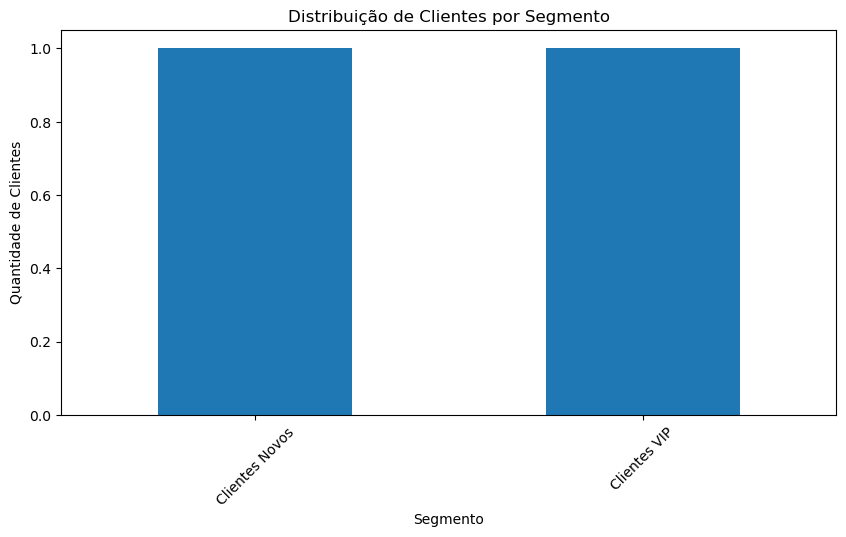

In [302]:
import matplotlib.pyplot as plt

segmentos = rfm['Segmento'].value_counts()

plt.figure(figsize=(10,5))
segmentos.plot(kind='bar')
plt.title('Distribuição de Clientes por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=45)
plt.show()


In [303]:
# Faturamento diário
faturamento_diario = df.groupby('Data')['Subtotal'].sum().reset_index()
faturamento_diario.columns = ['Data', 'Faturamento']


In [304]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Criar variável numérica de tempo
faturamento_diario['Dia_Num'] = np.arange(len(faturamento_diario))

X = faturamento_diario[['Dia_Num']]
y = faturamento_diario['Faturamento']

modelo = LinearRegression()
modelo.fit(X, y)

# Prever próximos 7 dias
dias_futuros = pd.DataFrame({
    'Dia_Num': np.arange(len(faturamento_diario), len(faturamento_diario) + 7)
})

previsao = modelo.predict(dias_futuros)

previsao_df = pd.DataFrame({
    'Dia_Futuro': range(1,8),
    'Faturamento_Previsto': previsao
})

print(previsao_df)


   Dia_Futuro  Faturamento_Previsto
0           1            498.414968
1           2            499.641337
2           3            500.867707
3           4            502.094077
4           5            503.320447
5           6            504.546816
6           7            505.773186


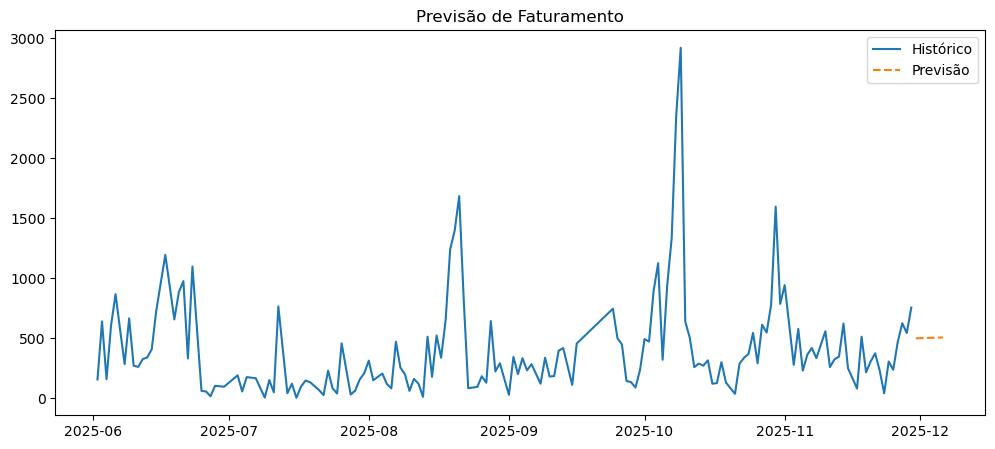

In [308]:
plt.figure(figsize=(12,5))
plt.plot(faturamento_diario['Data'], faturamento_diario['Faturamento'], label='Histórico')
plt.plot(
    pd.date_range(faturamento_diario['Data'].max(), periods=8, freq='D')[1:],
    previsao,
    linestyle='--',
    label='Previsão'
)
plt.title('Previsão de Faturamento')
plt.legend()
plt.show()


In [309]:
def classificar_cliente(row):
    if row['R_Score'] == 5 and row['F_Score'] == 5:
        return 'Clientes VIP'
    elif row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Clientes Fiéis'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 4:
        return 'Clientes em Risco'
    elif row['R_Score'] >= 4 and row['Frequency'] == 1:
        return 'Clientes Novos'
    else:
        return 'Clientes Regulares'


In [310]:
rfm['Segmento'] = rfm.apply(classificar_cliente, axis=1)
rfm['Segmento'].value_counts(normalize=True) * 100


Segmento
Clientes Regulares    50.0
Clientes VIP          50.0
Name: proportion, dtype: float64

In [311]:
rfm[['R_Score','F_Score','M_Score']].describe()



,R_Score,F_Score,M_Score
count,2.000000,2.000000,2.000000
mean,3.000000,3.000000,3.000000
std,2.828427,2.828427,2.828427
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000
50%,3.000000,3.000000,3.000000
75%,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000


In [312]:
rfm['R_Score'].value_counts().sort_index()
rfm['F_Score'].value_counts().sort_index()
rfm['M_Score'].value_counts().sort_index()


M_Score
1    1
5    1
Name: count, dtype: int64

In [295]:
# -------------------------------
# 10. Salvar CSV final tratado
# -------------------------------
df.to_csv("vendas_tratadas_completas.csv", index=False, encoding="utf-8")
